DATASET CARGADO
Registros: 9240
Columnas: 37


,Prospect ID,Lead Number,Lead Origin,Lead Source,Do Not Email,Do Not Call,Converted,TotalVisits,Total Time Spent on Website,Page Views Per Visit,...,Get updates on DM Content,Lead Profile,City,Asymmetrique Activity Index,Asymmetrique Profile Index,Asymmetrique Activity Score,Asymmetrique Profile Score,I agree to pay the amount through cheque,A free copy of Mastering The Interview,Last Notable Activity
0,7927b2df-8bba-4d29-b9a2-b6e0beafe620,660737,API,Olark Chat,No,No,0,0.0,0,0.0,...,No,Select,Select,02.Medium,02.Medium,15.0,15.0,No,No,Modified
1,2a272436-5132-4136-86fa-dcc88c88f482,660728,API,Organic Search,No,No,0,5.0,674,2.5,...,No,Select,Select,02.Medium,02.Medium,15.0,15.0,No,No,Email Opened
2,8cc8c611-a219-4f35-ad23-fdfd2656bd8a,660727,Landing Page Submission,Direct Traffic,No,No,1,2.0,1532,2.0,...,No,Potential Lead,Mumbai,02.Medium,01.High,14.0,20.0,No,Yes,Email Opened
3,0cc2df48-7cf4-4e39-9de9-19797f9b38cc,660719,Landing Page Submission,Direct Traffic,No,No,0,1.0,305,1.0,...,No,Select,Mumbai,02.Medium,01.High,13.0,17.0,No,No,Modified
4,3256f628-e534-4826-9d63-4a8b88782852,660681,Landing Page Submission,Google,No,No,1,2.0,1428,1.0,...,No,Select,Mumbai,02.Medium,01.High,15.0,18.0,No,No,Modified



Valores nulos:


Lead Source                                        36
TotalVisits                                       137
Page Views Per Visit                              137
Last Activity                                     103
Country                                          2461
Specialization                                   1438
How did you hear about X Education               2207
What is your current occupation                  2690
What matters most to you in choosing a course    2709
Tags                                             3353
Lead Quality                                     4767
Lead Profile                                     2709
City                                             1420
Asymmetrique Activity Index                      4218
Asymmetrique Profile Index                       4218
Asymmetrique Activity Score                      4218
Asymmetrique Profile Score                       4218
dtype: int64

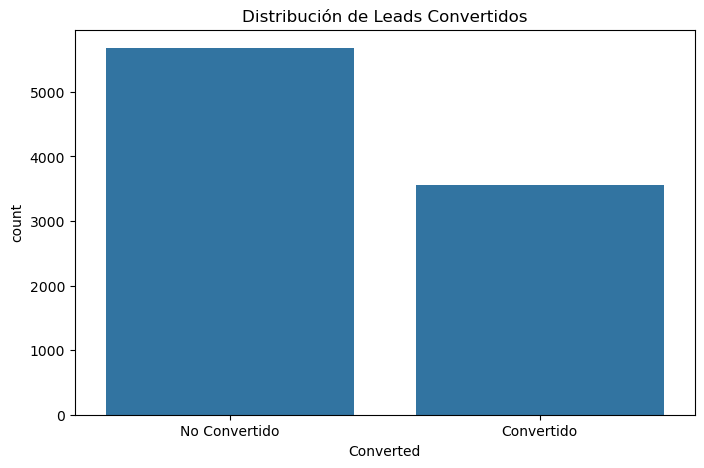


LIMPIEZA DE DATOS

Columnas eliminadas:
['Lead Quality', 'Asymmetrique Activity Index', 'Asymmetrique Profile Index', 'Asymmetrique Activity Score', 'Asymmetrique Profile Score']

Datos limpiados correctamente

FEATURE ENGINEERING
Variables categóricas codificadas

Datos divididos
Entrenamiento: 7392
Prueba: 1848

MODELO PREDICTIVO - RANDOM FOREST

Modelo entrenado correctamente

Predicciones realizadas

RESULTADOS DEL MODELO

Accuracy: 0.9150
ROC-AUC: 0.9612

Interpretación:
Excelente capacidad predictiva


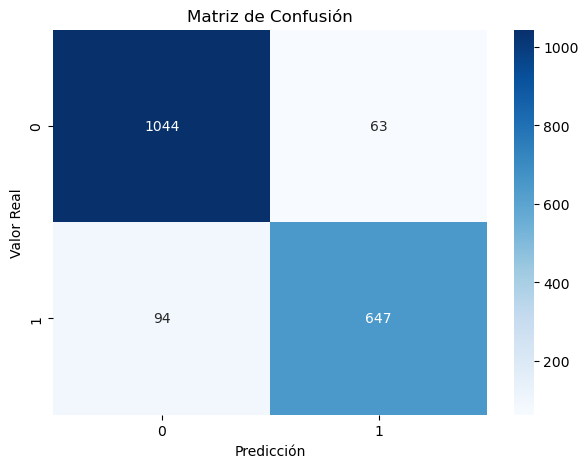

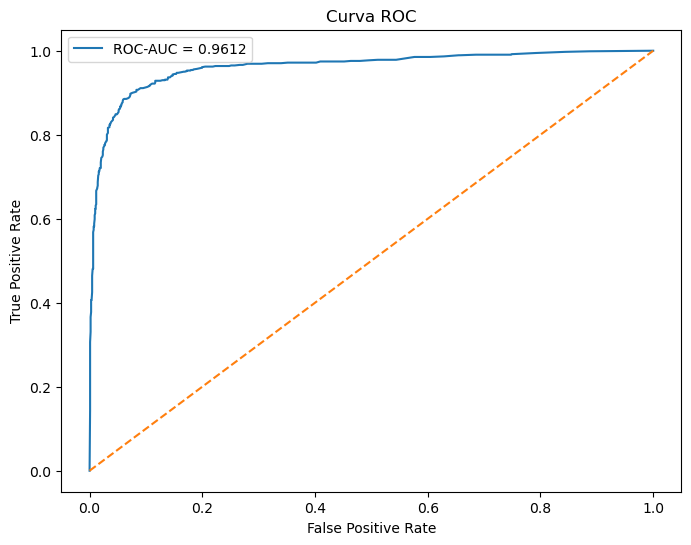


TOP VARIABLES MÁS IMPORTANTES


,Variable,Importancia
5,Total Time Spent on Website,0.214454
21,Tags,0.195749
28,Last Notable Activity,0.087417
24,Lead Profile,0.086636
7,Last Activity,0.062661
9,Specialization,0.048923
1,Lead Source,0.046662
0,Lead Origin,0.046069
4,TotalVisits,0.043079
6,Page Views Per Visit,0.042864


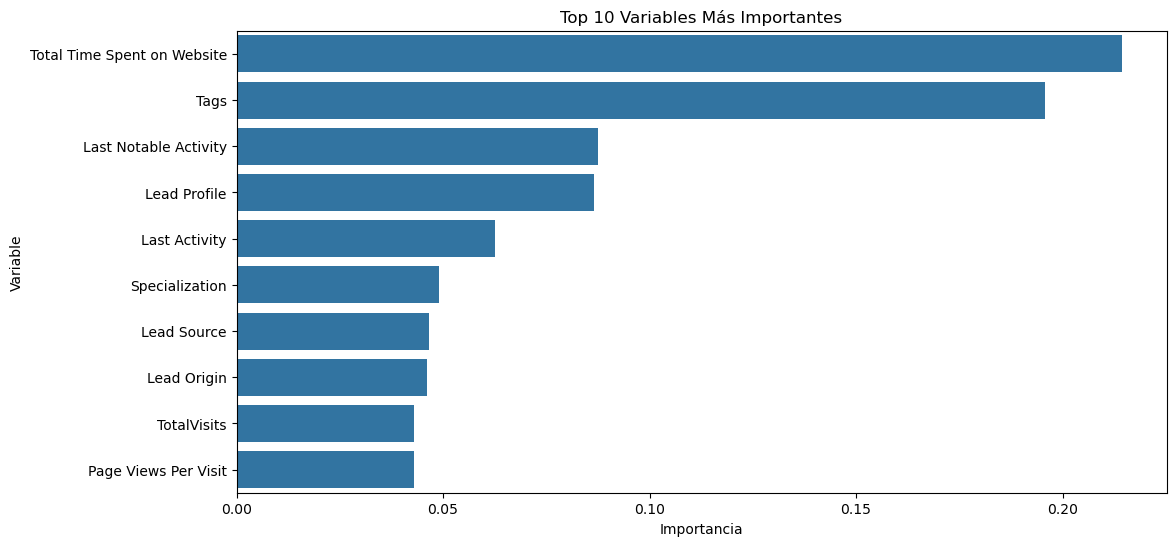


TOP 10 LEADS MÁS IMPORTANTES


,Lead,Probabilidad de Conversión (%),Prioridad
0,1,100.0,Alta
1,2,100.0,Alta
2,3,100.0,Alta
3,4,100.0,Alta
4,5,100.0,Alta
5,6,100.0,Alta
6,7,100.0,Alta
7,8,100.0,Alta
8,9,100.0,Alta
9,10,100.0,Alta


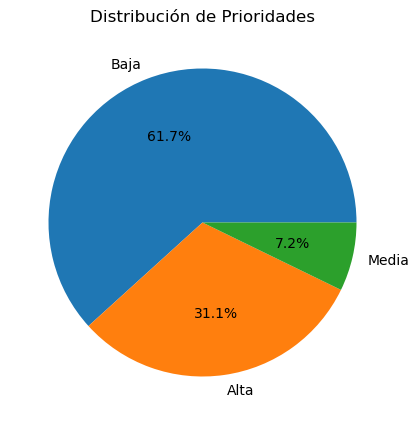


Archivo exportado:
lead_scoring_results.csv

PROYECTO FINALIZADO CORRECTAMENTE


In [2]:
# ==========================================
# PROYECTO FINAL - MINERÍA DE DATOS
# LEAD SCORING PREDICTIVO
# ==========================================

# ==========================================
# IMPORTACIÓN DE LIBRERÍAS
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

# ==========================================
# CARGAR DATASET
# ==========================================

df = pd.read_csv('Leads.csv')

print("="*60)
print("DATASET CARGADO")
print("="*60)

print(f"Registros: {df.shape[0]}")
print(f"Columnas: {df.shape[1]}")

display(df.head())

# ==========================================
# EXPLORACIÓN DE DATOS
# ==========================================

print("\nValores nulos:")

nulls = df.isnull().sum()

display(nulls[nulls > 0])

# ==========================================
# VISUALIZACIÓN VARIABLE OBJETIVO
# ==========================================

plt.figure(figsize=(8,5))

sns.countplot(
    x='Converted',
    data=df
)

plt.title('Distribución de Leads Convertidos')

plt.xticks(
    [0,1],
    ['No Convertido', 'Convertido']
)

plt.show()

# ==========================================
# LIMPIEZA DE DATOS
# ==========================================

print("\nLIMPIEZA DE DATOS")

# eliminar columnas irrelevantes

cols_to_drop = [
    'Prospect ID',
    'Lead Number'
]

for col in cols_to_drop:

    if col in df.columns:

        df.drop(col, axis=1, inplace=True)

# eliminar columnas con muchos nulos

null_percentage = (
    df.isnull().sum() / len(df)
) * 100

cols_null = null_percentage[
    null_percentage > 40
].index

print("\nColumnas eliminadas:")

print(list(cols_null))

df.drop(cols_null, axis=1, inplace=True)

# rellenar valores nulos

for col in df.columns:

    if df[col].dtype == 'object':

        df[col] = df[col].fillna(
            df[col].mode()[0]
        )

    else:

        df[col] = df[col].fillna(
            df[col].median()
        )

print("\nDatos limpiados correctamente")

# ==========================================
# FEATURE ENGINEERING
# ==========================================

print("\nFEATURE ENGINEERING")

le = LabelEncoder()

for col in df.columns:

    if df[col].dtype == 'object':

        df[col] = le.fit_transform(
            df[col]
        )

print("Variables categóricas codificadas")

# ==========================================
# VARIABLES
# ==========================================

X = df.drop('Converted', axis=1)

y = df['Converted']

# ==========================================
# ESCALADO DE DATOS
# ==========================================

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# ==========================================
# DIVISIÓN DE DATOS
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

print("\nDatos divididos")

print(f"Entrenamiento: {X_train.shape[0]}")
print(f"Prueba: {X_test.shape[0]}")

# =========================================================
# CREACIÓN DEL MODELO PREDICTIVO
# =========================================================
# AQUÍ SE CREA EL MODELO QUE PREDICE
# QUÉ LEADS TIENEN MAYOR PROBABILIDAD
# DE CONVERTIRSE EN CLIENTES
# =========================================================

print("\n" + "="*60)
print("MODELO PREDICTIVO - RANDOM FOREST")
print("="*60)

model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

# entrenamiento del modelo

model.fit(X_train, y_train)

print("\nModelo entrenado correctamente")

# =========================================================
# PREDICCIÓN
# =========================================================
# EL MODELO ANALIZA LOS DATOS
# Y PREDICE SI EL LEAD
# SE CONVERTIRÁ O NO
# =========================================================

y_pred = model.predict(X_test)

# probabilidad de conversión

y_prob = model.predict_proba(X_test)[:,1]

print("\nPredicciones realizadas")

# =========================================================
# EVALUACIÓN DEL MODELO
# =========================================================

accuracy = accuracy_score(
    y_test,
    y_pred
)

auc = roc_auc_score(
    y_test,
    y_prob
)

print("\n" + "="*60)
print("RESULTADOS DEL MODELO")
print("="*60)

print(f"\nAccuracy: {accuracy:.4f}")

print(f"ROC-AUC: {auc:.4f}")

# interpretación

if auc > 0.9:

    print("\nInterpretación:")
    print("Excelente capacidad predictiva")

elif auc > 0.8:

    print("\nInterpretación:")
    print("Muy buen modelo predictivo")

elif auc > 0.7:

    print("\nInterpretación:")
    print("Modelo aceptable")

else:

    print("\nInterpretación:")
    print("Modelo necesita mejoras")

# ==========================================
# MATRIZ DE CONFUSIÓN
# ==========================================

cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(7,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Matriz de Confusión')

plt.xlabel('Predicción')

plt.ylabel('Valor Real')

plt.show()

# ==========================================
# CURVA ROC
# ==========================================

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob
)

plt.figure(figsize=(8,6))

plt.plot(
    fpr,
    tpr,
    label=f'ROC-AUC = {auc:.4f}'
)

plt.plot(
    [0,1],
    [0,1],
    linestyle='--'
)

plt.title('Curva ROC')

plt.xlabel('False Positive Rate')

plt.ylabel('True Positive Rate')

plt.legend()

plt.show()

# ==========================================
# VARIABLES MÁS IMPORTANTES
# ==========================================

importance = pd.DataFrame({

    'Variable': X.columns,
    'Importancia': model.feature_importances_

})

importance = importance.sort_values(
    by='Importancia',
    ascending=False
)

print("\nTOP VARIABLES MÁS IMPORTANTES")

display(importance.head(10))

plt.figure(figsize=(12,6))

sns.barplot(
    data=importance.head(10),
    x='Importancia',
    y='Variable'
)

plt.title('Top 10 Variables Más Importantes')

plt.show()

# =========================================================
# RANKING DE LEADS
# =========================================================
# EL MODELO ASIGNA UNA PROBABILIDAD
# DE CONVERSIÓN A CADA LEAD
# =========================================================

lead_scores = model.predict_proba(
    X_scaled
)[:,1]

ranking = df.copy()

ranking['Lead_Score'] = lead_scores

# ==========================================
# SISTEMA DE PRIORIZACIÓN
# ==========================================

def priority(score):

    if score >= 0.8:
        return 'Alta'

    elif score >= 0.5:
        return 'Media'

    else:
        return 'Baja'

ranking['Prioridad'] = ranking[
    'Lead_Score'
].apply(priority)

# ==========================================
# TOP 10 LEADS
# ==========================================

top10 = ranking.sort_values(
    by='Lead_Score',
    ascending=False
).head(10)

top10 = top10.reset_index()

top10_display = pd.DataFrame({

    'Lead': top10.index + 1,

    'Probabilidad de Conversión (%)':
        (top10['Lead_Score'] * 100).round(2),

    'Prioridad':
        top10['Prioridad']

})

print("\n" + "="*60)
print("TOP 10 LEADS MÁS IMPORTANTES")
print("="*60)

display(top10_display)

# ==========================================
# VISUALIZACIÓN PRIORIDADES
# ==========================================

plt.figure(figsize=(8,5))

prioridades = ranking[
    'Prioridad'
].value_counts()

plt.pie(
    prioridades,
    labels=prioridades.index,
    autopct='%1.1f%%'
)

plt.title('Distribución de Prioridades')

plt.show()

# ==========================================
# EXPORTAR RESULTADOS
# ==========================================

ranking.to_csv(
    'lead_scoring_results.csv',
    index=False
)

print("\nArchivo exportado:")
print("lead_scoring_results.csv")

print("\nPROYECTO FINALIZADO CORRECTAMENTE")

In [4]:
%pip install streamlit pandas numpy scikit-learn matplotlib seaborn


Note: you may need to restart the kernel to use updated packages.


In [3]:
import joblib

# guardar modelo
joblib.dump(model, "lead_model.pkl")

# guardar scaler
joblib.dump(scaler, "scaler.pkl")

# guardar encoders
joblib.dump(le, "encoders.pkl")

# guardar columnas
joblib.dump(X.columns.tolist(), "columns.pkl")

print("Archivos PKL guardados correctamente")

Archivos PKL guardados correctamente
